# Проект. Исследование стартапов

## Введение

* Целью проекта является исследовать динамику и структуру финансирования стартапов и ответить на поставленные вопросы, важные для оценки инвестиционных стратегий. 
* Выявить наилучшую инвестиционную стратегию. 

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации

Загрузка необходимых библиотек.


In [1]:
!pip install phik -U
!pip install --upgrade pip
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix
from matplotlib.patches import Patch

     |████████████████████████████████| 677 kB 2.3 MB/s eta 0:00:01
     |████████████████████████████████| 1.8 MB 2.8 MB/s eta 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 21.1.3
    Uninstalling pip-21.1.3:
      Successfully uninstalled pip-21.1.3


Создаем 2 датафрейма 

Датафрейм `df_cb_investments` для файла `cb_investments.zip`

Датафрейм `df_cb_returns` для файла `cb_returns.csv`

In [2]:
df_cb_investments = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)
df_cb_returns = pd.read_csv('https://code.s3.yandex.net/datasets/cb_returns.csv', index_col=0)

Получение основной информации `df_cb_investments` и первых 7 строк.

In [3]:
df_cb_investments.info()
df_cb_investments.head(7)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Xavier University,http://www.xavier.edu/,NaN,NaN,"1,90,00,000",operating,USA,OH,Cincinnati,Cincinnati,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Tulane University,http://tulane.edu/,|Education|,Education,"1,20,00,000",operating,USA,LA,New Orleans,New Orleans,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Получение основной информации `df_cb_returns` и первых 7 строк.

In [4]:
df_cb_returns.info()
df_cb_returns.head(20)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15 entries, 2000 to 2014
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   seed                  15 non-null     float64
 1   venture               15 non-null     float64
 2   equity_crowdfunding   15 non-null     float64
 3   undisclosed           15 non-null     float64
 4   convertible_note      15 non-null     float64
 5   debt_financing        15 non-null     float64
 6   angel                 15 non-null     float64
 7   grant                 15 non-null     float64
 8   private_equity        15 non-null     float64
 9   post_ipo_equity       15 non-null     float64
 10  post_ipo_debt         15 non-null     float64
 11  secondary_market      15 non-null     float64
 12  product_crowdfunding  15 non-null     float64
dtypes: float64(13)
memory usage: 1.6 KB


,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00


В ходе загрузки информации с датафреймами следует произвести следующие операции. Датафрейм `df_cb_investments` требуется убрать лишние пробелы, проверить пропуски и при необходимости заполнить их, а также уменьшить разрядность некоторых столбцов с числовыми данными и изменить их тип. Датафрейм `df_cb_returns` уменьшить разрядность столбцов с числовыми данными. Именам столбцов в датафрейме `df_cb_returns` будет добавлено `_returns` для исключения конфликта повторяющихся столбцов.

### 1.2. Предобработка данных

Убираем лишние пробелы в названии столбцов датафрейма `df_cb_investments`.

In [5]:
df_cb_investments.columns = df_cb_investments.columns.str.strip()
display(df_cb_investments.columns[3: 5])

Index(['market', 'funding_total_usd'], dtype='object')

Изменяем названия для исключения конфликтов при возможном объединении датафреймов. Каждому названию столбцов датафрейма `df_cb_returns` добавлено "_returns".

In [6]:
new_name = []
for col in df_cb_returns.columns:
    new_name.append(f"{col}_returns")
df_cb_returns.columns = new_name
display(df_cb_returns.columns)

Index(['seed_returns', 'venture_returns', 'equity_crowdfunding_returns',
       'undisclosed_returns', 'convertible_note_returns',
       'debt_financing_returns', 'angel_returns', 'grant_returns',
       'private_equity_returns', 'post_ipo_equity_returns',
       'post_ipo_debt_returns', 'secondary_market_returns',
       'product_crowdfunding_returns'],
      dtype='object')

In [7]:
display(df_cb_investments['funding_total_usd'])

0         9,00,00,000 
1           20,00,000 
2           90,00,000 
3           77,00,000 
4            5,40,000 
             ...      
54289              NaN
54290              NaN
54291              NaN
54292              NaN
54293              NaN
Name: funding_total_usd, Length: 54294, dtype: object

Убераем в столбце `funding_total_usd` выделение разрядов и приводим их к числовому типу.

In [8]:
df_cb_investments['funding_total_usd'] = df_cb_investments['funding_total_usd'].str.replace(',', '')
df_cb_investments['funding_total_usd'] = df_cb_investments['funding_total_usd'].str.replace('-', '')
df_cb_investments['funding_total_usd'] = df_cb_investments['funding_total_usd'].str.strip()

df_cb_investments['funding_total_usd'] = pd.to_numeric(df_cb_investments['funding_total_usd'], downcast ='float')
display(df_cb_investments['funding_total_usd'].head(5))
#display(df_cb_investments.iloc[19858])

0    90000000.0
1     2000000.0
2     9000000.0
3     7700000.0
4      540000.0
Name: funding_total_usd, dtype: float32

Убираем лишние пробелы и приводим к нижнему регистру в столбце `market`.

In [9]:
df_cb_investments['market'] = df_cb_investments['market'].str.strip().str.lower()
df_cb_investments['market'].head(10)

0            education
1                  NaN
2    business services
3            education
4            education
5                  NaN
6            education
7            education
8                  NaN
9         social media
Name: market, dtype: object

Обработайте типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.

Изменяем тип данных в столбцах `first_funding_at`, `last_funding_at`, `mid_funding_at`.

In [10]:
df_cb_investments['first_funding_at'] = pd.to_datetime(df_cb_investments['first_funding_at'], errors='coerce')
df_cb_investments['last_funding_at'] = pd.to_datetime(df_cb_investments['last_funding_at'], errors='coerce')
df_cb_investments['mid_funding_at'] = pd.to_datetime(df_cb_investments['mid_funding_at'], errors='coerce')


Обработайте полные дубликаты в данных и пропуски в `funding_total_usd`. избавьтесь от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [11]:
general = pd.DataFrame({'Пропущенные значения':df_cb_investments.isna().sum(),
'Доля пропущенных значений (в %)':(df_cb_investments.isna().sum() / len(df_cb_investments) * 100)})

display(general)

,Пропущенные значения,Доля пропущенных значений (в %)
name,4857,8.945740
homepage_url,8305,15.296350
category_list,8817,16.239363
market,8817,16.239363
funding_total_usd,13387,24.656500
status,6170,11.364055
country_code,10129,18.655837
state_code,24133,44.448742
region,10129,18.655837
city,10972,20.208494


In [12]:
df_first = df_cb_investments.shape[0]
display(df_first) 

54294

Выводим количество дубликатов по столбцу `name`.

In [13]:
df_cb_investments['name'].duplicated().value_counts()

False    49351
True      4943
Name: name, dtype: int64

Удаляем дубликаты по столбцу `name`.

In [14]:
df_cb_investments = df_cb_investments.drop_duplicates(subset='name')
display(f'Колличество строк до удаления дубликатов: {df_first}',
f'Колличество удаленных дубликатов: {df_first - df_cb_investments.shape[0]}',
f'Доля удаленных дубликатов: {1 - (df_cb_investments.shape[0] /  df_first)}')

'Колличество строк до удаления дубликатов: 54294'

'Колличество удаленных дубликатов: 4943'

'Доля удаленных дубликатов: 0.09104136737024349'

Заполните пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмите приблизительно середину интервала между этими двумя датами.

Оцените размер оставшихся пропусков в столбце.

In [15]:
#Вычисляем среднее значение между двумя датами first_funding_at и last_funding_at.
avg_stat = (df_cb_investments['last_funding_at'] - df_cb_investments['first_funding_at']).mean()
# Заполняем пропуски средним значением. 
df_cb_investments['mid_funding_at'] = df_cb_investments['mid_funding_at'].fillna(avg_stat)
display(df_cb_investments['mid_funding_at'].isna().sum())

0

Оцените полноту данных и сделайте предварительный вывод о том, достаточно ли данных для решения задач проекта. Какой процент данных был отброшен?

In [16]:
display(f'Колличество строк до удаления дубликатов: {df_first}',
f'Колличество удаленных дубликатов: {df_first - df_cb_investments.shape[0]}',
f'Доля удаленных дубликатов: {(1 - (df_cb_investments.shape[0] /  df_first))*100}',
f'Колличество строк после удаления дубликатов: {df_cb_investments.shape[0]}')

'Колличество строк до удаления дубликатов: 54294'

'Колличество удаленных дубликатов: 4943'

'Доля удаленных дубликатов: 9.104136737024348'

'Колличество строк после удаления дубликатов: 49351'

Название столбцов были откорректированы. Тип данных в столбцах first_funding_at, last_funding_at, mid_funding_at был изменен на datetime. В столбце funding_total_usd были убраны ненужные символы, данные были приведены к единому виду, а также тип данных был изменен на float.
В ходе предварительной обработки данных были выявлены дубликаты в размере 9% от общего числа данных, что составляет 4943 удаленных дубликатов. Итоговое количество строк после обработки данных составило 49351.

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Делим компании на 3 группы.

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируем соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.


Делим компании на 3 группы.

In [17]:
from datetime import timedelta
# переменная для 1 года.
interval = timedelta(days=365)

def categorize(value):
    if value['funding_rounds'] == 1:
        return 'Единичное финансирование'
        
    duration = value['last_funding_at'] - value['first_funding_at']

    if duration <= interval:
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'

df_cb_investments['financing_category'] = df_cb_investments.apply(categorize, axis=1)

func = df_cb_investments['financing_category'].value_counts(normalize=True)
display(round(func*100, 2))

Единичное финансирование          64.80
Срок финансирования более года    25.53
Срок финансирования до года        9.67
Name: financing_category, dtype: float64

Распределение общего числа компаний по группам в процентах.

Text(0.5, 1.0, 'Распределение общего числа компаний по группам.')

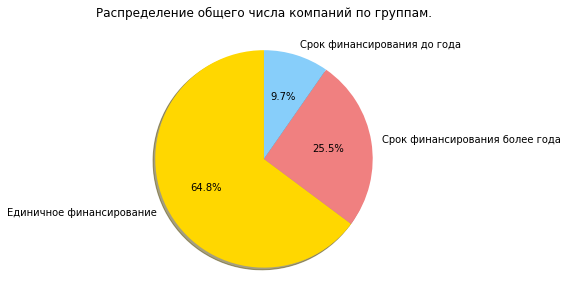

In [18]:

color = ['gold', 'lightcoral', 'lightskyblue']
plt.figure(figsize=(5, 5))
plt.pie(
    func,
    colors = color,
    labels = func.index,
    autopct='%1.1f%%',  # Отображение процентов с 1 знаком после запятой
    shadow=True,
    startangle=90,
)
plt.title('Распределение общего числа компаний по группам.')

Распределение общего объёма привлечённых средств по группам.

financing_category
Единичное финансирование          1.987501e+11
Срок финансирования более года    4.024489e+11
Срок финансирования до года       4.885036e+10
Name: funding_total_usd, dtype: float32

Text(0.5, 1.0, 'Распределение общего объёма привлечённых средств по группам.')

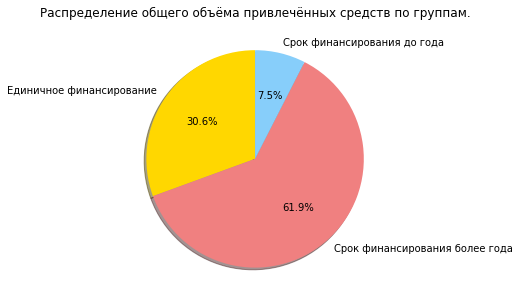

In [19]:
category_share = df_cb_investments.groupby('financing_category')['funding_total_usd'].sum()
display(category_share)

plt.figure(figsize=(5, 5))
plt.pie(
    category_share,
    colors = color,
    labels = func.index,
    autopct='%1.1f%%',  # Отображение процентов с 1 знаком после запятой
    shadow=True,
    startangle=90,
)
plt.title('Распределение общего объёма привлечённых средств по группам.')

В ходе разделения компаний на 3 группы было выявлено, что наибольшее количество компаний обладают единичным финансированием, в то время как срок финансирования от года вовлекает наибольшее количество привлеченных средств. 
   * Процент компаний с единичным финансированием составляет 64,8%. 
   * Объем привлеченных средств при сроке финансирования более года составляет 61,9%.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитайте, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесите к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесите к средним, а сегменты до 35 компаний отнесите к нишевым. Рассчитайте, сколько сегментов попадает в каждую из категорий.

Постройте график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты.

Создаём датафрейм с сегментами рынка.

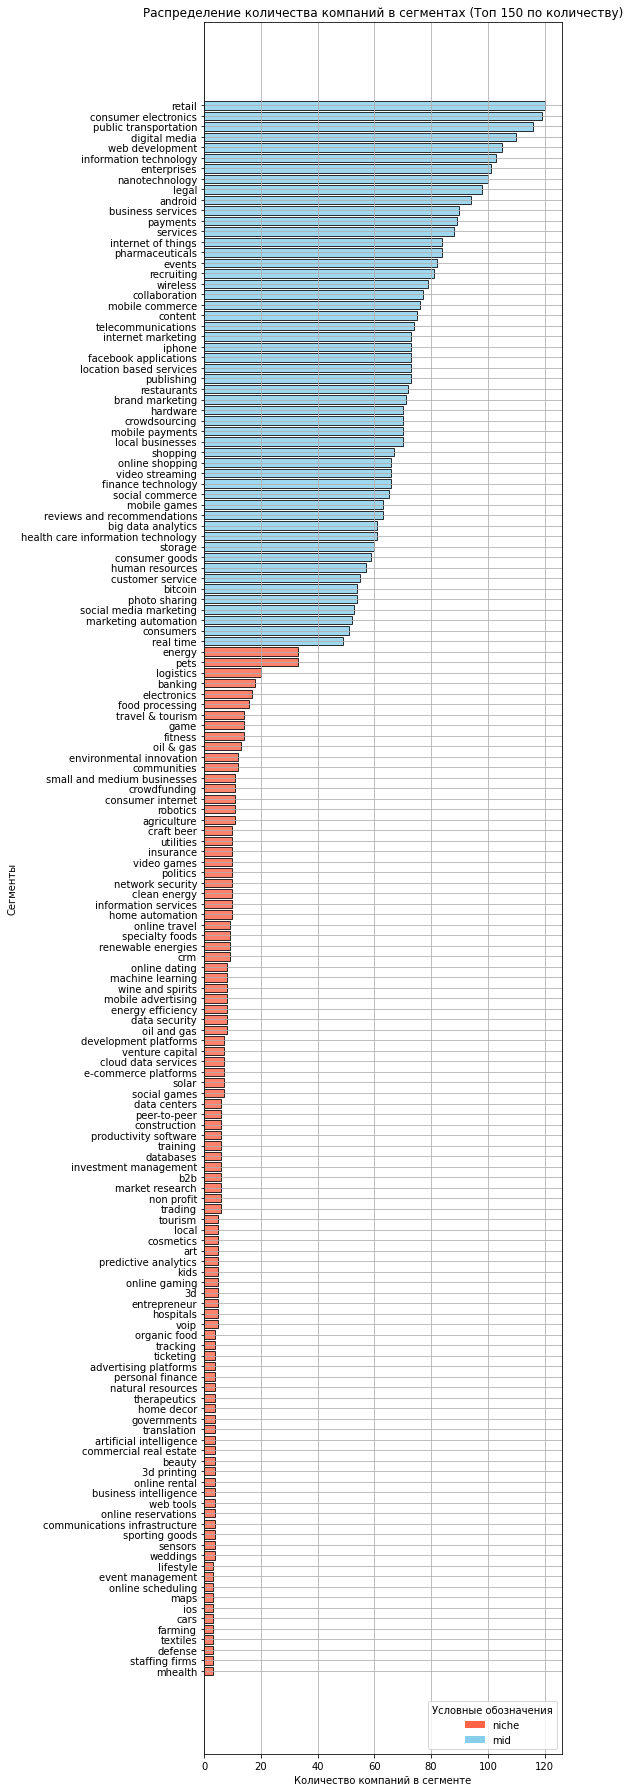

In [20]:
df_segment = df_cb_investments['market'].value_counts().reset_index(name='count') 

# 1. Подсчёт и правильное именование колонок
df_segment = (
    df_cb_investments['market']
    .value_counts()
    .reset_index(name='count')
)

# 2. Функция сегментации
def segment(col):
    if col['count'] > 120:
        return 'Массовый сегмент'
    elif 35 <= col['count'] <= 120:
        return 'mid'
    else:
        return 'niche'

# 3. Добавляем колонку 'segment'
df_segment['segment'] = df_segment.apply(segment, axis=1)

# 4. Фильтрация: убираем массовые сегменты, берём топ‑150, сортируем
df_segments_nomax = df_segment[df_segment['segment'] != 'Массовый сегмент']
df_segments_nomax = df_segments_nomax.head(150).sort_values('count')


# 5. Цвета для графика
color_map = {
    'Массовый сегмент': '#FFD700',  # золотой
    'mid': '#87CEEB',           # небесно‑голубой
    'niche': '#FF6347'         # томатный
}
colors = df_segments_nomax['segment'].map(color_map).fillna('green')

# 6. Построение графика
plt.figure(figsize=(8, 25))
plt.barh(
    df_segments_nomax['index'],      # названия сегментов (было 'market' — ошибка!)
    df_segments_nomax['count'],     # количество компаний
    color=colors,
    edgecolor='black',
    alpha=0.8
)

# 7. Легенда
legend_elements = [
    Patch(facecolor=color_map['niche'], label='niche'),
    Patch(facecolor=color_map['mid'], label='mid')
]
plt.legend(
    handles=legend_elements,
    title='Условные обозначения',
    loc='lower right'
)

plt.title('Распределение количества компаний в сегментах (Топ 150 по количеству)')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Сегменты')
plt.tight_layout()
plt.grid()
plt.show()


            segment  count
0               mid   3955
1             niche   1092
2  Массовый сегмент  40353


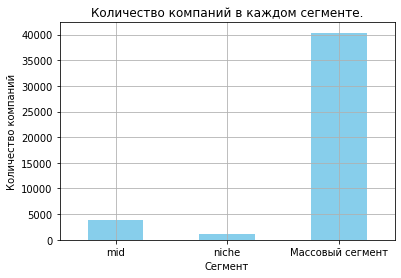

In [21]:
df_bar = df_segment.groupby('segment')['count'].sum().reset_index()
print(df_segment.groupby('segment')['count'].sum().reset_index())

df_bar.plot(kind='bar',
       x='segment',
       y='count',
       color='#87CEEB',
       legend=False,
        rot=0,
        xlabel='Сегмент',
        ylabel='Количество компаний',
        title='Количество компаний в каждом сегменте.')
plt.grid()

Редактируем основной датафрейм.

In [22]:

df_cb_investments['market'] = df_cb_investments['market']

def segment_column(col, freq_map):
    if pd.isna(col):
        return 'unknown'
        
    count = freq_map[col]

    if count > 120:
        return col  #оригинальное название
    elif 35 <= count <= 120:
        return 'mid'     #средний сегмент
    else:
        return 'niche' #нишевый сегмент
        
market = df_cb_investments['market'].value_counts()
df_cb_investments['market'] = (
    df_cb_investments['market']
    .apply(segment_column, args=(market,))
)

#df_cb_investments['market'] = df_cb_investments['market'].apply(segment_column)
df_cb_investments['market'].value_counts()


software                5481
mid                     3955
unknown                 3951
biotechnology           3759
mobile                  2719
e-commerce              2280
curated web             2086
enterprise software     1557
games                   1373
clean technology        1322
health care             1294
advertising             1275
social media            1171
hardware + software     1154
niche                   1092
education               1023
finance                 1004
health and wellness      989
manufacturing            787
analytics                759
security                 626
consulting               525
semiconductors           522
hospitality              502
web hosting              479
real estate              434
fashion                  423
travel                   413
news                     402
search                   356
messaging                344
saas                     332
music                    328
internet                 298
medical       

Оставьте в столбце `market` только массовые сегменты. Для остальных сегментов замените значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполняйте с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.


Наибольшее количество компаний находится в массовом сегменте. Наибольшее количество в среднем сегменте у `Medical Devices`, а в нишевом сегменте у `Analytics`.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Оценка, размера общего финансирования для одной компании будет типичным, а какой — выбивающимся.

Выводим общую информацию `funding_total_usd`

In [23]:
pd.options.display.float_format = '{:.2f}'.format
display(df_cb_investments['funding_total_usd'].describe())

count         40837.00
mean       15918145.00
std       168815712.00
min               1.00
25%          350000.00
50%         2000000.00
75%        10000000.00
max     30079502336.00
Name: funding_total_usd, dtype: float64

Медиана и среднее значение сильно отличаются, следует проверить наличие аномально больших значений или выбросов.

Text(0.5, 1.0, 'Распределение (Без выбросов)')

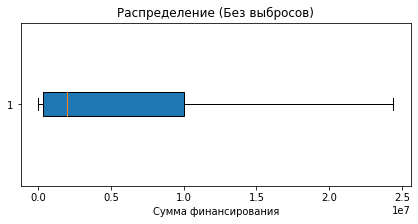

In [24]:

plt.figure(figsize=(7, 3))
plt.boxplot(df_cb_investments['funding_total_usd'].dropna(),
           whis=1.5,
           vert=False,
           showfliers=False,
           patch_artist=True)
plt.xlabel('Сумма финансирования')
plt.title('Распределение (Без выбросов)')


Определение сегмента рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведите топ таких сегментов.

Рассчитываем типичный размер общего финансирования для одной компании.

In [25]:
tipical = df_cb_investments.groupby('market')['funding_total_usd'].agg(
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
).reset_index()
tipical['iqr'] = tipical['q3'] - tipical['q1']
tipical['low'] = tipical['q1'] - 1.5 * tipical['iqr']
tipical['up'] = tipical['q3'] + 1.5 * tipical['iqr']

tipical = tipical.sort_values(by='up', ascending=False)
display(tipical.head(15))

,market,q1,q3,iqr,low,up
44,semiconductors,4329717.50,32625000.00,28295282.00,-38113208.00,75067920.00
6,clean technology,1500000.00,28120000.00,26620000.00,-38430000.00,68050000.00
21,health care,1250000.00,27700000.00,26450000.00,-38425000.00,67375000.00
50,technology,450000.00,24300000.00,23850000.00,-35325000.00,60075000.00
55,web hosting,1855000.00,25000000.00,23145000.00,-32862500.00,59717500.00
5,biotechnology,1500000.00,22046056.00,20546056.00,-29319084.00,52865140.00
28,medical devices,762498.50,18590624.00,17828126.00,-25979690.00,45332812.00
51,transportation,250000.00,17400000.00,17150000.00,-25475000.00,43125000.00
13,enterprise software,1000000.00,15000000.00,14000000.00,-20000000.00,36000000.00
43,security,1012500.00,14460000.00,13447500.00,-19158750.00,34631248.00


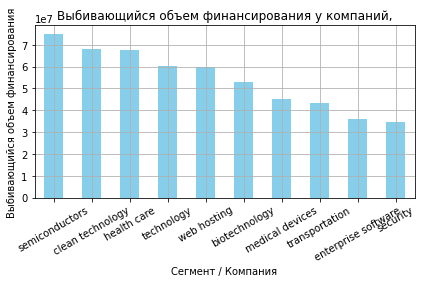

In [26]:

# Построение столбчатого графика
tipical.head(10).sort_values(by='up',ascending=False).plot(
    kind='bar',
    x='market',
    y='up',
    color='skyblue',
    legend=False,
    rot=30 
)


plt.xlabel('Сегмент / Компания')
plt.ylabel('Выбивающийся объем финансирования')
plt.title('Выбивающийся объем финансирования у компаний,')
plt.grid()
plt.tight_layout()
plt.show()

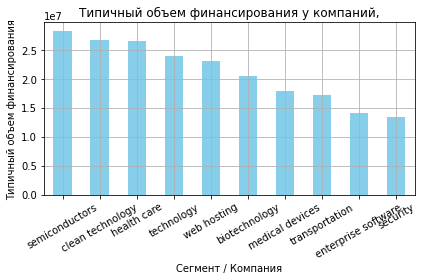

In [27]:
tipical.head(10).sort_values(by='iqr',ascending=False).plot(
    kind='bar',
    x='market',
    y='iqr',
    color='skyblue',
    legend=False,
    rot=30 
)


plt.xlabel('Сегмент / Компания')
plt.ylabel('Типичный объем финансирования')
plt.title('Типичный объем финансирования у компаний,')
plt.grid()
plt.tight_layout()
plt.show()

Наиболее выбивающийся объем финансирования у таких компаний, как `semiconductors`,`clean technology`,`health care`. Наибольший типичный объем финансирования также принадлежит этим компаниям. 

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии



Проверяем полноту данных за 2014 год.

In [28]:
df_2014 = df_cb_investments[df_cb_investments['last_funding_at'].dt.year == 2014]
months_df_2014 = sorted(df_2014['last_funding_at'].dt.month.unique())
display(f'Месяцы, в которые происходило финансирование в 2014 году. {months_df_2014}')

'Месяцы, в которые происходило финансирование в 2014 году. [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]'

Данные за 2014 год можно считать полными. Финансирование происходило в каждый из 12 месяцев.

In [29]:
#Верхняя и нижняя граница. 
Q1 = df_cb_investments['funding_total_usd'].quantile(0.25)
Q3 = df_cb_investments['funding_total_usd'].quantile(0.75)
IQR = Q3 - Q1
low = Q1 - 1.5 * IQR
up = Q3 + 1.5 * IQR
#Условие для определения аномалий.
anomaly = (df_cb_investments['funding_total_usd'] < low) | (df_cb_investments['funding_total_usd'] > up)
# Создаём чистый df без аномалий.
df_clean = df_cb_investments[~anomaly]



Фильтрация по условиям: количество финансирования в определенные года больше 50.

In [30]:
df_clean['mid_funding_at'] = pd.to_datetime(df_clean['mid_funding_at'], errors='coerce')
#Создаем столбец с годами 
df_clean['year'] = df_clean['mid_funding_at'].dt.year
#Смотрим, в какие года было 50 и более раундов финансирования. 
count_year = df_clean.groupby('year')['year'].count()
display(count_year)


pd.options.mode.chained_assignment = None

/tmp/ipykernel_63/776553848.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['mid_funding_at'] = pd.to_datetime(df_clean['mid_funding_at'], errors='coerce')
/tmp/ipykernel_63/776553848.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['year'] = df_clean['mid_funding_at'].dt.year


year
1960.00       2
1973.00       1
1974.00       2
1984.00       3
1985.00       1
1987.00       2
1989.00       1
1990.00       1
1992.00       1
1993.00       2
1994.00       1
1995.00       5
1996.00       4
1997.00       5
1998.00      18
1999.00      28
2000.00      42
2001.00      35
2002.00      42
2003.00      57
2004.00     102
2005.00     703
2006.00    1180
2007.00    1704
2008.00    2014
2009.00    2045
2010.00    2961
2011.00    4345
2012.00    4909
2013.00    5716
Name: year, dtype: int64

In [31]:
#Года для фильтрации 50+ раундов.
year_50 = count_year[count_year >= 50].index
display(year_50)

Float64Index([2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0,
              2011.0, 2012.0, 2013.0],
             dtype='float64', name='year')

In [32]:
df_year = df_clean[df_clean['year'].isin(year_50)]
df_year['year'].unique()

array([2009., 2013., 2007., 2012., 2010., 2008., 2011., 2005., 2004.,
       2006., 2003.])

До 2002 года было зафиксировано 50 или меньше раундов финансирования. Финансирование раньше 2003 года было отсеяно, чистый датафрейм имеет название `df_year`. Также были удалены аномальные записи. 

### 3.3. Анализ типов финансирования по объёму и популярности

Постройте график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируйтесь на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также постройте график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравните графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

In [33]:
financ = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding']
sum_fin = df_year[financ].astype(bool).sum().sort_values(ascending=False)
print(sum_fin)

venture                 13897
seed                     7942
debt_financing           2237
angel                    2086
grant                     574
private_equity            460
undisclosed               363
convertible_note          254
product_crowdfunding      105
post_ipo_equity            51
equity_crowdfunding        47
post_ipo_debt               6
secondary_market            1
dtype: int64


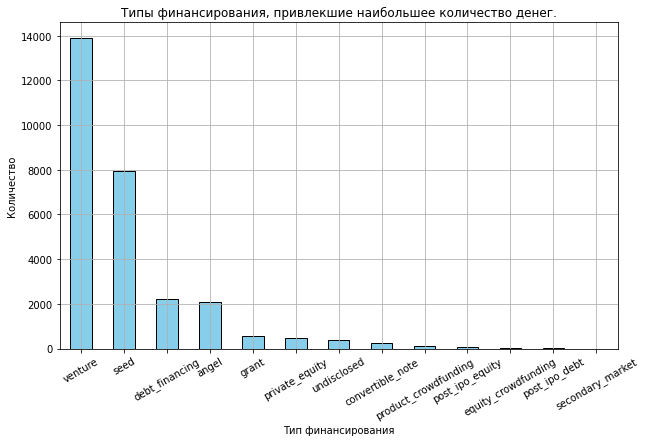

In [34]:
sum_fin.plot(
    kind='bar',
    figsize=(10, 6),
    color='skyblue',
    edgecolor='black',
    rot=30
)
plt.title('Типы финансирования, привлекшие наибольшее количество денег.')
plt.xlabel('Тип финансирования')
plt.ylabel('Количество')
plt.grid()

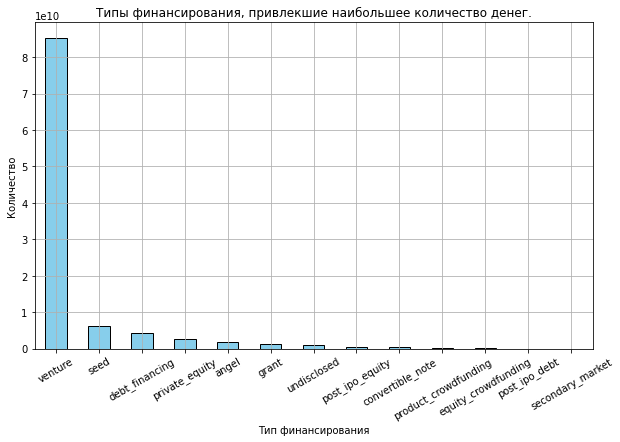

In [35]:
sum_fin1 = df_year[financ].sum().sort_values(ascending=False)
sum_fin1.plot(
    kind='bar',
    figsize=(10, 6),
    color='skyblue',
    edgecolor='black',
    rot=30
)
plt.title('Типы финансирования, привлекшие наибольшее количество денег.')
plt.xlabel('Тип финансирования')
plt.ylabel('Количество')
plt.grid()


Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

seed_returns                    15
venture_returns                 15
undisclosed_returns             15
debt_financing_returns          15
angel_returns                   15
post_ipo_equity_returns         15
secondary_market_returns        15
convertible_note_returns        14
private_equity_returns          13
equity_crowdfunding_returns      9
product_crowdfunding_returns     6
post_ipo_debt_returns            4
grant_returns                    0
dtype: int64


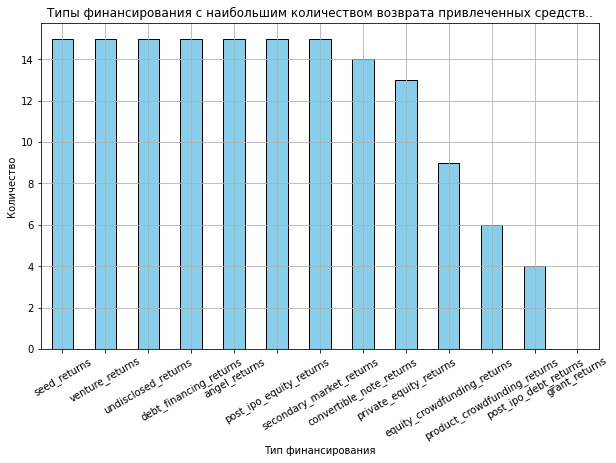

In [36]:
return_fin = ['seed_returns', 'venture_returns', 'equity_crowdfunding_returns', 'undisclosed_returns',
    'convertible_note_returns', 'debt_financing_returns', 'angel_returns', 'grant_returns',
    'private_equity_returns', 'post_ipo_equity_returns', 'post_ipo_debt_returns',
    'secondary_market_returns', 'product_crowdfunding_returns']
sum_return = df_cb_returns[return_fin].astype(bool).sum().sort_values(ascending=False)
print(sum_return)
sum_return.plot(
    kind='bar',
    figsize=(10, 6),
    color='skyblue',
    edgecolor='black',
    rot=30
)
plt.title('Типы финансирования с наибольшим количеством возврата привлеченных средств..')
plt.xlabel('Тип финансирования')
plt.ylabel('Количество')
plt.grid()

Типом финансирования, привлекшим наибольшее количество средств, является `venture`. Наименьшее количество — `secondary_market`.
Возврат привлеченных средств наибольший у `seed` и наименьший у `grant`.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитываем для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы строим графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

In [37]:
# df_financing = df_year.groupby('market').agg({
#     'funding_total_usd':'sum',
#     'funding_rounds':'sum'})
# #total_rows = df_financing.apply(len).sum()
# #display(total_rows , df_year.shape[0])
# df_year['avg_round'] = df_financing['funding_total_usd'] / df_financing['funding_rounds'] #Средний размер раунда
# df_year['avg_round'] = df_financing_last.sort_values(ascending=False)
# display(df_year['avg_round'].unique())
df_year['avg_rounds'] = df_year['funding_total_usd'] / df_year['funding_rounds']
df_year = df_year[df_year['funding_rounds'] > 0] #Избегаем деления на 0
#Считаем средний за каждый год 
avg_round_year = df_year.groupby('year')['avg_rounds'].mean()
avg_round_year.head(100).sort_values(ascending=False)

year
2005.00   5534781.67
2006.00   5028479.55
2004.00   4973385.91
2007.00   3908544.55
2008.00   3467836.94
2003.00   3325535.30
2009.00   2985070.96
2010.00   2784297.46
2011.00   2279362.34
2013.00   2243044.91
2012.00   2051539.68
Name: avg_rounds, dtype: float64

Строим график на основе полученных результатов. 

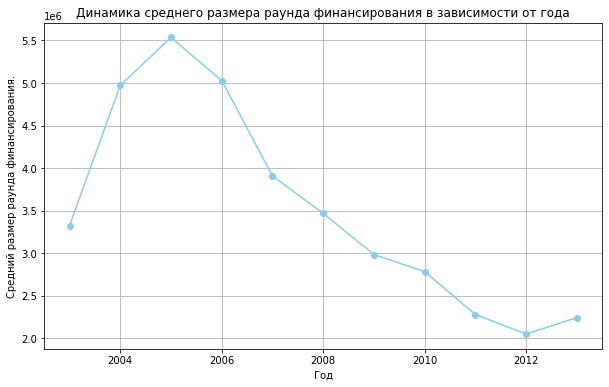

In [38]:
plt.figure(figsize=(10, 6))
avg_round_year.plot(kind='line', marker='o', color='skyblue')
plt.title('Динамика среднего размера раунда финансирования в зависимости от года')
plt.xlabel('Год')
plt.ylabel('Средний размер раунда финансирования.')
plt.grid()
plt.show()


In [39]:
max_round_year = df_year.groupby('year')['funding_rounds'].sum()
max_round_year.head(100).sort_values(ascending=False)

year
2013.00   9438.00
2012.00   8483.00
2011.00   7280.00
2010.00   5211.00
2009.00   3689.00
2008.00   3503.00
2007.00   2870.00
2006.00   1804.00
2005.00    918.00
2004.00    173.00
2003.00    103.00
Name: funding_rounds, dtype: float64

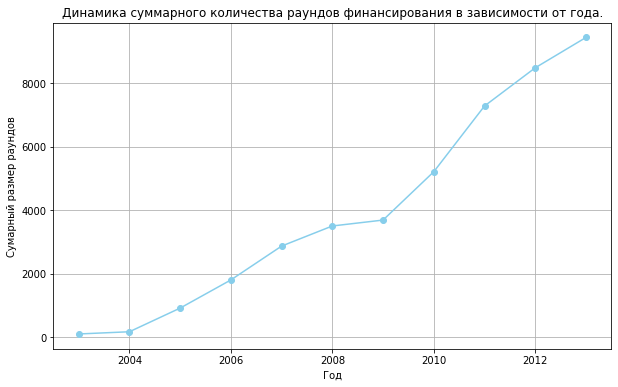

In [40]:
plt.figure(figsize=(10, 6))
max_round_year.plot(kind='line', marker='o', color='skyblue')
plt.title('Динамика суммарного количества раундов финансирования в зависимости от года.')
plt.xlabel('Год')
plt.ylabel('Сумарный размер раундов')
plt.grid()
plt.show()

Средний размер раунда финансирования показывает, что пик финансирования приходился на 2004–2006 годы, с наивысшей точкой в 2005 году и наименьшей в 2012 году. В то время как количество раундов финансирования постепенно росло и на 2014 год является максимальным.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составьте сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберите из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразите, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматривайте только массовые сегменты, а средние и нишевые исключите.

На основе графика сделайте вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

Рассматриваемые года изменены на 2012–2013, поскольку 2014 год отсеялся из-за выбросов.

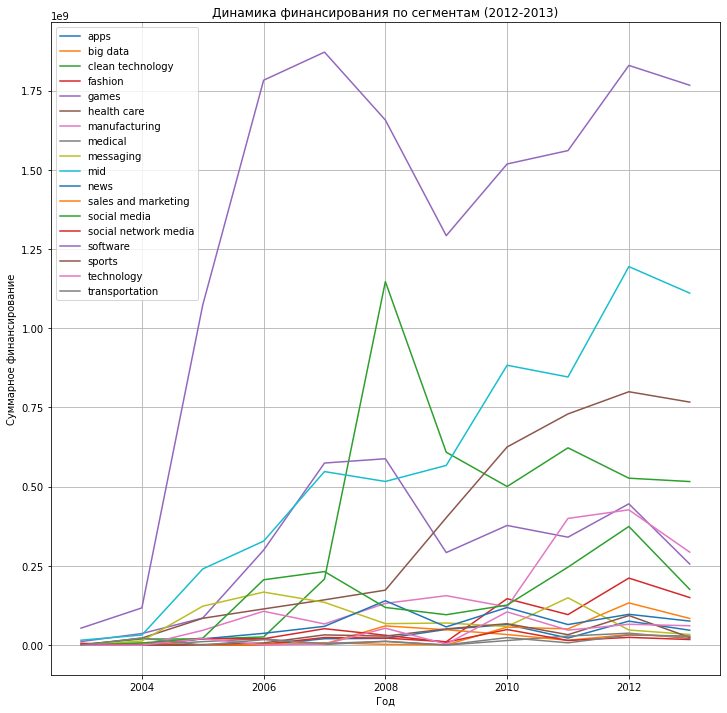

In [41]:
#task_5 = df_year.groupby(['market', 'year'])['funding_total_usd'].sum().unstack(fill_value=0)
#  Сводная таблица
task_5 = df_year.groupby(['market', 'year'])['funding_total_usd'].sum().unstack(fill_value=0)

# Отбор сегментов с ростом 2013→2014
growth_segments = task_5[(task_5[2012] > task_5[2013])]
selected_markets = growth_segments.index.tolist()


plot_data = task_5.loc[selected_markets]

# График
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 12))
for market in selected_markets:
    plt.plot(plot_data.columns, plot_data.loc[market], label=market)
plt.xlabel('Год')
plt.ylabel('Суммарное финансирование')
plt.title('Динамика финансирования по сегментам (2012-2013)')
plt.legend()
plt.grid(True)
plt.show()


Наилучшим сегментом на 2012–2013 год является `software`. 

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Промежуточная задача:
Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

Объединяем датафреймы

In [42]:
df = pd.merge(df_year, df_cb_returns, on='year', how='left')
df = df[['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'seed_returns', 'venture_returns', 'equity_crowdfunding_returns', 'undisclosed_returns', 'convertible_note_returns', 'debt_financing_returns', 'angel_returns', 'grant_returns', 'private_equity_returns', 'post_ipo_equity_returns', 'post_ipo_debt_returns', 'secondary_market_returns', 'product_crowdfunding_returns']]


df = df.groupby('year').sum()
# df['seed_share'] = df['seed_returns'] / (df['seed'])
# display(df)

import numpy as np

# Список типов финансирования (без _returns)
financing_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
    'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
    'post_ipo_debt', 'secondary_market', 'product_crowdfunding'
]

# Для каждого типа рассчитываем долю возврата: returns / финансирование
for ft in financing_types:
    returns_col = f"{ft}_returns"   # столбец с возвратами
    financing_col = ft               # столбец с объёмом финансирования
    ratio_col = f"{ft}_share"       # имя нового столбца с долей
    
    # Расчёт с защитой от деления на ноль
    df[ratio_col] = df[returns_col] / (df[financing_col] + 1e-60)


# Опционально: заменяем аномально большие значения на NaN (например, > 1000%)
OUTLIER_THRESHOLD = 10.0
for ft in financing_types:
    ratio_col = f"{ft}_share"
    df.loc[df[ratio_col] > OUTLIER_THRESHOLD, ratio_col] = np.nan
    df.loc[df[ratio_col] < 0, ratio_col] = np.nan  # если отрицательные — тоже NaN


# Показываем результат
display(df)


,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,...,undisclosed_share,convertible_note_share,debt_financing_share,angel_share,grant_share,private_equity_share,post_ipo_equity_share,post_ipo_debt_share,secondary_market_share,product_crowdfunding_share
year,,,,,,,,,,,,,,,,,,,,,
2003.00,9208286.00,256240848.00,0.00,0.00,0.00,1050000.00,8771850.00,16850717.00,0.00,0.00,...,NaN,NaN,0.00,0.00,0.00,NaN,NaN,0.00,NaN,0.00
2004.00,15154728.00,610514233.00,0.00,40192945.00,0.00,19016623.00,11013741.00,10363600.00,0.00,0.00,...,0.00,NaN,0.00,0.00,0.00,NaN,NaN,0.00,NaN,0.00
2005.00,28659503.00,4222086696.00,0.00,17291819.00,0.00,63492932.00,58334621.00,5545000.00,5000000.00,4796022.00,...,0.00,NaN,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00
2006.00,68345889.00,7555240371.00,933057.00,31119216.00,11807857.00,108562125.00,70076153.00,1147500.00,11831724.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,NaN,0.00
2007.00,190008907.00,8955559794.00,0.00,50174436.00,10949054.00,181319954.00,200802441.00,17693300.00,70066766.00,12000000.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00
2008.00,290572031.00,9735610126.00,0.00,98140618.00,7987768.00,215477171.00,240842507.00,20285347.00,46546331.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.01,NaN,0.00,NaN,0.00
2009.00,270214647.00,8170686758.00,2049671.00,58369924.00,9397255.00,360519589.00,149075773.00,116507351.00,85853837.00,23482403.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00
2010.00,469543377.00,10575077915.00,7748000.00,166883664.00,38410936.00,537900299.00,198935699.00,204403463.00,191839659.00,12413500.00,...,0.00,0.00,0.00,0.00,0.00,0.01,0.03,0.00,NaN,0.00
2011.00,1085651462.00,11570780812.00,1400000.00,252334654.00,49887170.00,763691179.00,326414487.00,121845556.00,331530456.00,37153846.00,...,0.00,0.00,0.00,0.00,0.00,0.01,0.02,0.01,NaN,0.00


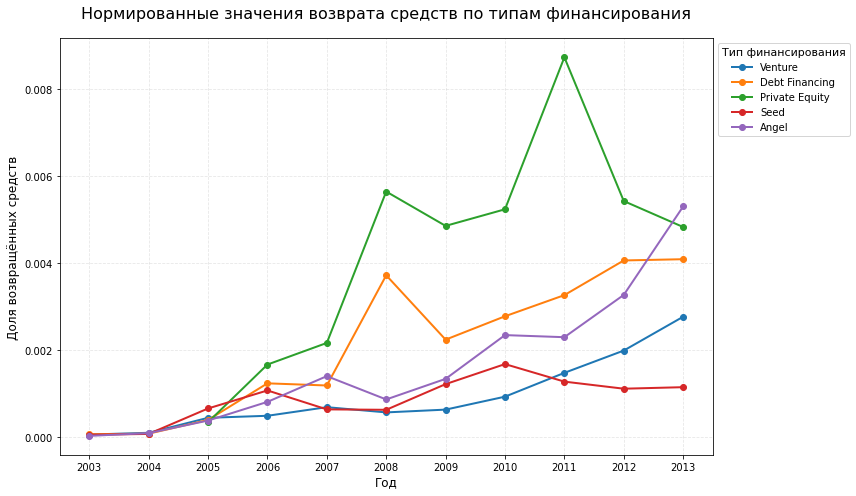

In [43]:
# Выбираем типы финансирования для графика
selected_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']
share_columns = [f"{ft}_share" for ft in selected_types]

# Проверяем наличие нужных столбцов
missing = [col for col in share_columns if col not in df.columns]
if missing:
    raise ValueError(f"Нет столбцов в df: {missing}")

# Создаём график
plt.figure(figsize=(12, 7))

for col in share_columns:
    plt.plot(
        df.index,           # годы (индекс df)
        df[col],             # значения доли возврата
        marker='o',        # маркеры на точках
        linewidth=2,        # толщина линии
        label=col.replace('_share', '').replace('_', ' ').title()  # читаемый лейбл
    )

# Оформление графика
plt.title('Нормированные значения возврата средств по типам финансирования', fontsize=16, pad=20)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Доля возвращённых средств', fontsize=12)
plt.legend(title='Тип финансирования', title_fontsize=11, fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(df.index.astype(int))  # года как целые числа
plt.tight_layout()

# Показываем график
plt.show()

Строим график, на котором отображены нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Наиболее устойчивый рост значения возврата средств наблюдается у типа финансирования `angel` — сумма возвратов бизнес-ангелам.


## Шаг 5. Итоговый вывод и рекомендации

На 2015 год. Опираясь на результаты анализа, дайте рекомендацию заказчику:
* Наиболее выбивающийся объем финансирования у таких компаний, как `semiconductors`, `clean technology`, `health care`. Наибольший типичный объем финансирования также принадлежит этим компаниям. Поэтому я считаю, что данные отрасли являются наиболее перспективными на 2015 год. 

* Типом финансирования, привлекшим наибольшее количество средств, является `venture`. Возврат привлеченных средств наибольший у типа финансирования `venture` находится на 2 месте. Исходя из этих данных, считаю, что данный тип финансирования наиболее перспективный.


Подведите итоги проекта:
* Были проанализированы данные с двух датафреймов, построены графики для понимания происходящего в данных, а также для удобного анализа и принятия решений. 
В ходе разделения компаний на 3 группы было выявлено, что наибольшее количество компаний обладают единичным финансированием, в то время как срок финансирования от года вовлекает наибольшее количество привлеченных средств. Процент компаний с единичным финансированием составляет 64,8%. Объем привлеченных средств при сроке финансирования более года составляет 61,9%.

Наибольшее количество компаний находится в массовом сегменте. Наибольшее количество в среднем сегменте у Medical Devices, а в нишевом сегменте у Analytics.

Был проведен анализ объемов финансирования. Наиболее выбивающийся объем финансирования у таких компаний, как semiconductors,clean technology,health care. Наибольший типичный объем финансирования также принадлежит этим компаниям.

Также проанализированы типы финансирования. Типом финансирования, привлекшим наибольшее количество средств, является venture. Наименьшее количество — secondary_market. Возврат привлеченных средств наибольший у seed и наименьший у grant.

Изучена динамика финансирования. Средний размер раунда финансирования показывает, что пик финансирования приходился на 2004–2006 годы, с наивысшей точкой в 2005 году и наименьшей в 2012 году. В то время как количество раундов финансирования постепенно росло и на 2014 год является максимальным.

Изучена динамика доли возвращенных средств. Наиболее устойчивый рост значения возврата средств наблюдается у типа финансирования angel — сумма возвратов бизнес-ангелам.
